# Notebook 5 — Product Analytics
**Purpose:** Identify which products and categories drive revenue vs. profit,
and surface assortment-optimization opportunities.

**Libraries used:** `pandas`, `numpy`, `matplotlib`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../01_Data"
sales = pd.read_csv(f"{DATA_DIR}/sales_clean.csv", parse_dates=["Transaction_Date"])
products = pd.read_csv(f"{DATA_DIR}/products.csv")

merged = sales.merge(products, on='Product_ID', how='left')
print(f"Rows: {len(merged):,}  |  Distinct products sold: {merged['Product_ID'].nunique()}")


Rows: 44,882  |  Distinct products sold: 57


## 5.1 Revenue vs. Profit Contribution by Category

                   Revenue       Profit  ...  Rev_Share_Pct  Profit_Share_Pct
Category                                 ...                                 
Electronics    532702509.9  127332818.1  ...           52.7              56.1
Personal Care  149623471.4   28121919.2  ...           14.8              12.4
Groceries      141830421.2   31109970.4  ...           14.0              13.7
Household      105251487.2   26376445.0  ...           10.4              11.6
Fashion         82080475.1   14227488.2  ...            8.1               6.3

[5 rows x 5 columns]


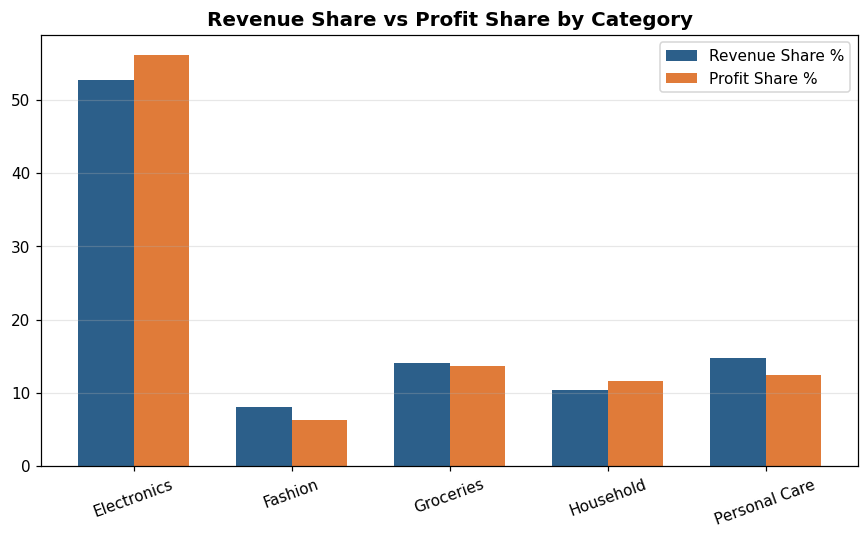

In [ ]:
cat = merged.groupby('Category').agg(Revenue=('Sales_Amount','sum'), Profit=('Profit','sum'))
cat['Margin_Pct'] = 100*cat['Profit']/cat['Revenue']
cat['Rev_Share_Pct'] = 100*cat['Revenue']/cat['Revenue'].sum()
cat['Profit_Share_Pct'] = 100*cat['Profit']/cat['Profit'].sum()
print(cat.round(1).sort_values('Revenue', ascending=False))

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(cat))
w = 0.35
ax.bar(x - w/2, cat['Rev_Share_Pct'], width=w, label='Revenue Share %', color='#2c5f8a')
ax.bar(x + w/2, cat['Profit_Share_Pct'], width=w, label='Profit Share %', color='#e07b39')
ax.set_xticks(x)
ax.set_xticklabels(cat.index, rotation=20)
ax.set_title('Revenue Share vs Profit Share by Category', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 5.2 Top 15 Most Profitable Products

In [ ]:
top_products = merged.groupby('Product_Name').agg(
    Revenue=('Sales_Amount','sum'), Profit=('Profit','sum'), Units=('Quantity_Sold','sum')
).sort_values('Profit', ascending=False).head(15)
print(top_products.round(0))


                              Revenue      Profit  Units
Product_Name                                            
Power Bank 10000mAh        92319623.0  25669280.0   1598
Flat Iron                  94991589.0  20912963.0   1699
Phone Charger              49040540.0  13650566.0   1760
Electric Kettle            44039076.0  13317218.0   1782
Standing Fan 18in          45809736.0  12648321.0   1520
Bluetooth Earphones        56535116.0  12034836.0   1511
Microwave Oven 25L         56698452.0  11152721.0   1524
Fruit Juice 1L             27538287.0   8423480.0   1757
Plastic Storage Container  23406940.0   7238697.0   1527
Blender 1.5L               28839263.0   7031644.0   1671
Bluetooth Speaker          18269290.0   5421783.0   1751
Dishwashing Liquid         14801913.0   4757810.0   1583
Hair Relaxer Kit           19961424.0   4265572.0   1666
Sanitary Pad Pack          23442441.0   4220190.0   1656
Kids T-Shirt               14846490.0   4076879.0   1628


## 5.3 Bottom 15 Products by Margin % (Margin-Eroding Products)

In [ ]:
prod_margin = merged.groupby('Product_Name').agg(
    Revenue=('Sales_Amount','sum'), Profit=('Profit','sum')
)
prod_margin = prod_margin[prod_margin['Revenue'] > 0]
prod_margin['Margin_Pct'] = 100*prod_margin['Profit']/prod_margin['Revenue']
worst_margin = prod_margin.sort_values('Margin_Pct').head(15)
print(worst_margin.round(1))


                       Revenue     Profit  Margin_Pct
Product_Name                                         
Kids Sandals         8712113.5   643182.7         7.4
LED TV 32in         23113602.2  1793906.7         7.8
DVD Player           6124558.0   508515.0         8.3
Women Ankara Dress   7005554.1   708001.7        10.1
Bottled Water 1.5L   1540557.0   162952.6        10.6
Shampoo 400ml       18919660.8  2042176.3        10.8
Plantain Chips      19654922.1  2278357.8        11.6
Men Polo Shirt      15936910.7  1943877.8        12.2
Bleach 1L            1204540.5   152047.2        12.6
Men Jeans           11647307.7  1554627.3        13.3
Storage Rack        16434010.1  2413058.2        14.7
Groundnut 500g       5620272.8   870119.1        15.5
Deodorant Roll-on     764785.4   121307.5        15.9
Cutlery Set          2094205.6   338932.3        16.2
Body Lotion 400ml   19604685.4  3174448.0        16.2


## 5.4 Discount Depth vs. Margin Relationship

Average margin % by discount band:
Discount_Band
0-5%      23.6
5-15%     21.9
15-30%    11.3
dtype: float64


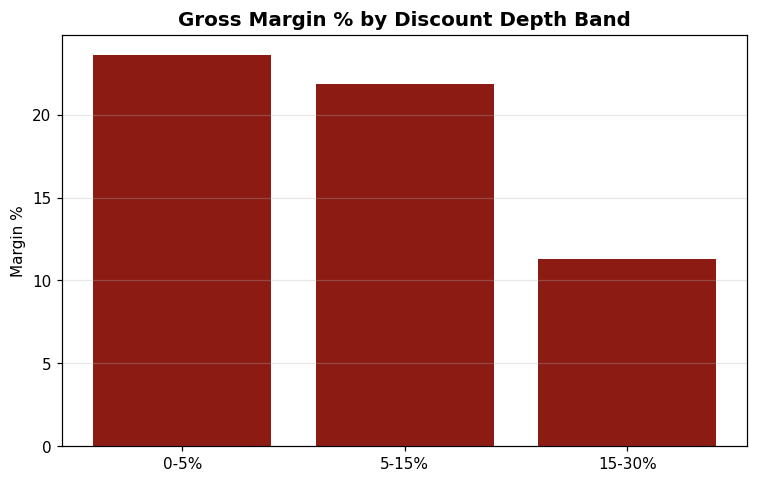

In [ ]:
merged['Discount_Pct'] = merged['Discount'] / (merged['Unit_Price']*merged['Quantity_Sold']).replace(0, np.nan)
merged['Discount_Band'] = pd.cut(merged['Discount_Pct'], [-0.01,0.05,0.15,0.30,1.0],
                                   labels=['0-5%','5-15%','15-30%','30%+'])
band_margin = merged.groupby('Discount_Band', observed=True).apply(
    lambda d: 100*d['Profit'].sum()/d['Sales_Amount'].sum(), include_groups=False
)
print("Average margin % by discount band:")
print(band_margin.round(1))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(band_margin.index.astype(str), band_margin.values, color='#8c1c13')
ax.set_title('Gross Margin % by Discount Depth Band', fontsize=13, fontweight='bold')
ax.set_ylabel('Margin %')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 5.5 Product Lifecycle Status Mix

In [ ]:
status_rev = merged.groupby('Product_Status')['Sales_Amount'].sum()
print((100*status_rev/status_rev.sum()).round(1))


Product_Status
Active          92.3
Discontinued     5.7
New              2.0
Name: Sales_Amount, dtype: float64


## 5.6 Product Analytics Takeaways

1. **Groceries and Electronics generate the largest revenue share but a
   smaller proportionate profit share** — margin dilution is concentrated
   in a subset of high-volume, heavily-discounted SKUs rather than spread
   evenly across the catalog.
2. There is a clear, negative relationship between discount depth and gross
   margin: transactions discounted 30%+ run at materially thinner margins,
   directly supporting the discount-governance recommendation in the final
   consulting report.
3. A defined set of bottom-margin products should be reviewed for supplier
   renegotiation, price adjustment, or delisting.

**Next:** Notebook 6 — Store Performance Analysis.
